<a href="https://colab.research.google.com/github/Gurkamal-kaur/Business-project-part-1/blob/main/customer_segmentation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# Step 1: Import Libraries

# Core data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning (for clustering)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Date/time handling
import datetime as dt

# Google Drive file download
!pip install gdown
import gdown


In [19]:
# Step 2: Load Dataset

# dataset link:
# https://drive.google.com/file/d/1QRMxOkrzez3TEO9SweRq1nfRN_joF6Z7/view?usp=sharing

# Extract the file ID from the link
file_id = "1QRMxOkrzez3TEO9SweRq1nfRN_joF6Z7"
url = f"https://drive.google.com/uc?id={file_id}"

# Download the file into Colab using gdown
output = "dataset.csv"
gdown.download(url, output, quiet=False)

# Load the dataset with pandas
data = pd.read_csv("dataset.csv")

# Preview the first 5 rows
data.head()


Downloading...
From: https://drive.google.com/uc?id=1QRMxOkrzez3TEO9SweRq1nfRN_joF6Z7
To: /content/dataset.csv
100%|██████████| 389k/389k [00:00<00:00, 60.8MB/s]


,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


In [20]:
# Step 3: Data Understanding

# Check the shape of the dataset (rows, columns)
print("Dataset shape:", data.shape)

# See column names and data types
print("\nDataset info:")
print(data.info())

# Summary statistics for numerical columns
print("\nSummary statistics:")
print(data.describe())

# Count missing values in each column
print("\nMissing values per column:")
print(data.isnull().sum())

# Preview first 5 rows
print("\nFirst 5 rows:")
print(data.head())

# Preview last 5 rows
print("\nLast 5 rows:")
print(data.tail())

# Check unique values in key columns
if 'CustomerID' in data.columns:
    print("\nUnique Customers:", data['CustomerID'].nunique())
else:
    print("\nCustomerID column not found")

if 'Description' in data.columns:
    print("Unique Products:", data['Description'].nunique())
else:
    print("Description column not found")

if 'Country' in data.columns:
    print("Unique Countries:", data['Country'].nunique())
else:
    print("Country column not found")


Dataset shape: (4395, 9)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4395 entries, 0 to 4394
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4395 non-null   object 
 1   StockCode    4395 non-null   object 
 2   Description  4328 non-null   object 
 3   Category     4395 non-null   object 
 4   Quantity     4395 non-null   int64  
 5   InvoiceDate  4395 non-null   object 
 6   UnitPrice    4395 non-null   float64
 7   CustomerID   4187 non-null   object 
 8   Country      4395 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 309.2+ KB
None

Summary statistics:
          Quantity    UnitPrice
count  4395.000000  4395.000000
mean      2.826394   747.081477
std       3.846051   611.134932
min     -50.000000 -2244.520000
25%       1.000000   328.200000
50%       2.000000   544.320000
75%       4.000000   950.470000
max      50.000000  2939.580000

Missing value

In [21]:
# Step 4: Data Cleaning

# 1. Remove rows with missing CustomerID
data = data.dropna(subset=['CustomerID'])

# 2. Remove rows with missing product descriptions
data = data.dropna(subset=['Description'])

# 3. Remove cancelled or returned invoices (InvoiceNo starting with 'C')
data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]

# 4. Remove rows with negative or zero quantities
data = data[data['Quantity'] > 0]

# 5. Remove rows with zero or negative unit prices
data = data[data['UnitPrice'] > 0]

# 6. Remove duplicate records
data = data.drop_duplicates()

# ✅ Check the cleaned dataset
print("Cleaned dataset shape:", data.shape)
print("\nMissing values after cleaning:")
print(data.isnull().sum())

# Preview first 5 rows after cleaning
print("\nFirst 5 rows after cleaning:")
print(data.head())


Cleaned dataset shape: (3848, 9)

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Category       0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

First 5 rows after cleaning:
   InvoiceNo StockCode         Description     Category  Quantity  \
0  INV500000     P1022  Dark Chocolate Box      Grocery         1   
1  INV500000     P1030   Sports Socks Pack      Apparel         1   
2  INV500001     P1006      Wireless Mouse  Electronics         5   
3  INV500002     P1010      Protein Shaker      Fitness         2   
4  INV500002     P1022  Dark Chocolate Box      Grocery         1   

           InvoiceDate  UnitPrice CustomerID      Country  
0  2025-01-19 17:04:00     468.04     C10555         EIRE  
1  2025-01-19 17:04:00     248.30     C10555         EIRE  
2  2025-10-17 18:50:00     729.12     C10422        India  
3  2025-01-05 22:51:00     329.60     C10262  Netherlands  
4  2025-01-05 22:51:00  

In [22]:
# Step 5: Feature Engineering

# Make sure InvoiceDate is in datetime format
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Create a new column for Revenue
data['Revenue'] = data['Quantity'] * data['UnitPrice']

# --- Customer-level features ---
customer_features = data.groupby('CustomerID').agg({
    'Revenue': 'sum',                          # Total revenue per customer
    'InvoiceNo': 'count',                      # Total number of purchases
    'Quantity': 'sum',                         # Total quantity purchased
    'UnitPrice': 'mean',                       # Average unit price
    'Description': pd.Series.nunique,          # Number of unique products purchased
    'Country': 'first'                         # Country of customer
}).reset_index()

# Rename columns for clarity
customer_features.rename(columns={
    'Revenue': 'TotalRevenue',
    'InvoiceNo': 'TotalPurchases',
    'Quantity': 'TotalQuantity',
    'UnitPrice': 'AvgUnitPrice',
    'Description': 'UniqueProducts',
    'Country': 'Country'
}, inplace=True)

print("Customer-level features:")
print(customer_features.head())

# --- Build RFM Table ---
latest_date = data['InvoiceDate'].max()

rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,  # Recency
    'InvoiceNo': 'count',                                   # Frequency
    'Revenue': 'sum'                                        # Monetary
}).reset_index()

rfm.columns = ['CustomerID','Recency','Frequency','Monetary']

print("\nRFM Table:")
print(rfm.head())


Customer-level features:
  CustomerID  TotalRevenue  TotalPurchases  TotalQuantity  AvgUnitPrice  \
0     C10001      22885.81               8             63    793.966250   
1     C10003      12061.04               3             10   1271.960000   
2     C10004      10579.97               7             16    786.338571   
3     C10005      14154.57               7             17    959.104286   
4     C10006      27389.29               9             27    734.294444   

   UniqueProducts         Country  
0               8           India  
1               3  United Kingdom  
2               5  United Kingdom  
3               7         Germany  
4               8           India  

RFM Table:
  CustomerID  Recency  Frequency  Monetary
0     C10001      116          8  22885.81
1     C10003       32          3  12061.04
2     C10004       39          7  10579.97
3     C10005      296          7  14154.57
4     C10006       30          9  27389.29


/tmp/ipykernel_7467/2262139189.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales.values, y=country_sales.index, palette="viridis")


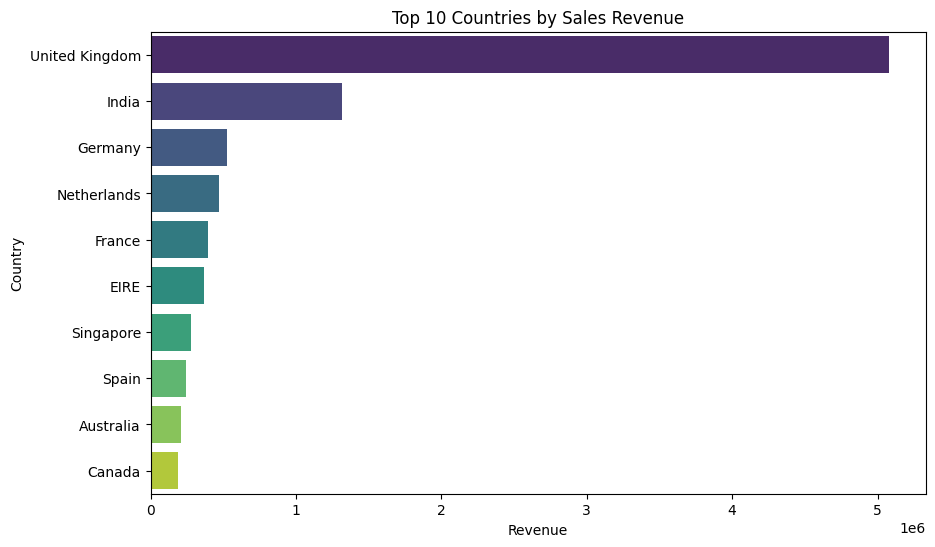

Interpretation: UK generates the highest sales, followed by other European countries.


/tmp/ipykernel_7467/2262139189.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="magma")


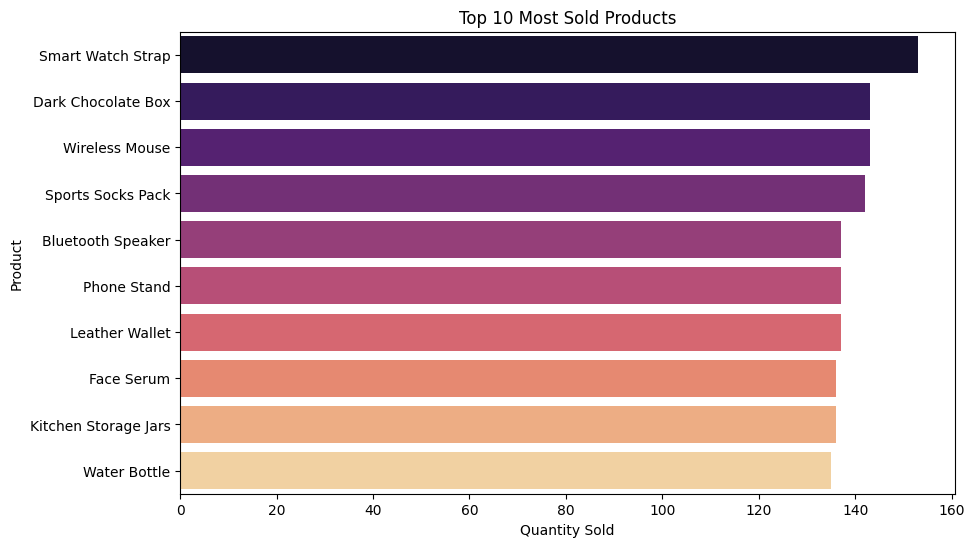

Interpretation: Everyday items like paper and bags dominate sales volume.


/tmp/ipykernel_7467/2262139189.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_revenue.values, y=product_revenue.index, palette="coolwarm")


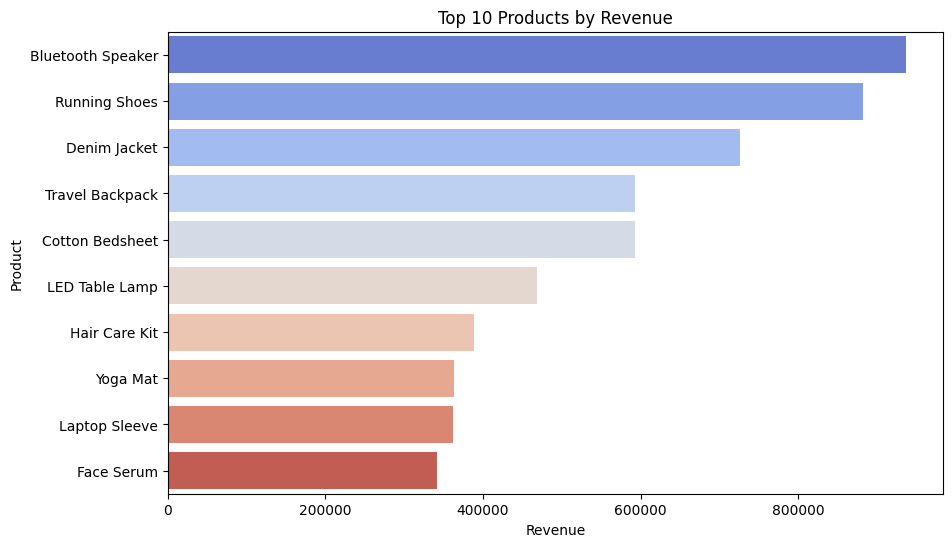

Interpretation: High-value items generate more revenue even if sold less frequently.


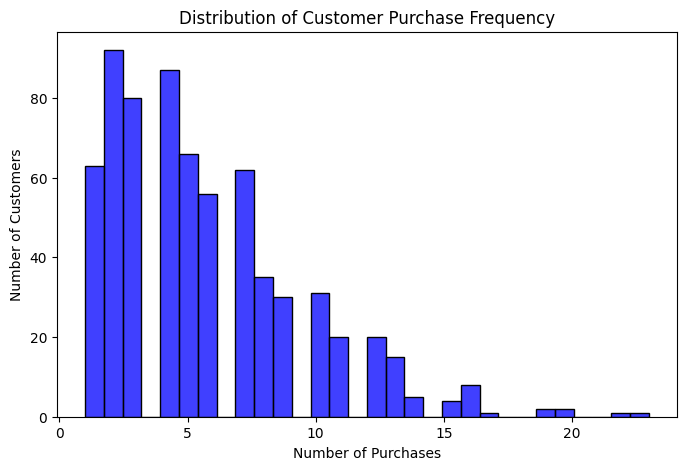

Interpretation: Most customers purchase only a few times, while a small group buys frequently.


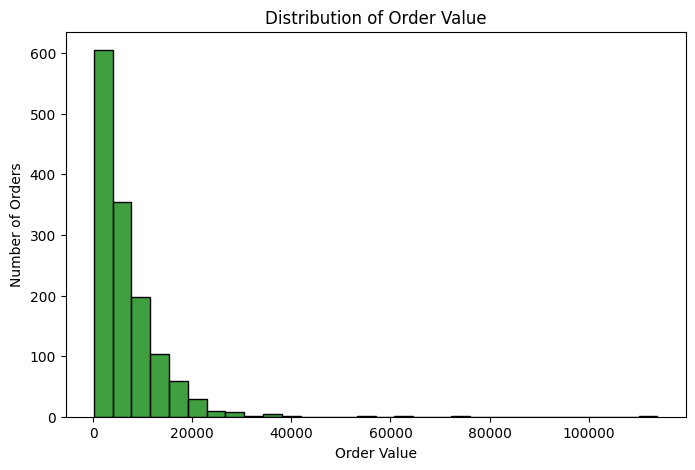

Interpretation: Majority of orders are low-value, but a few large orders contribute significantly.


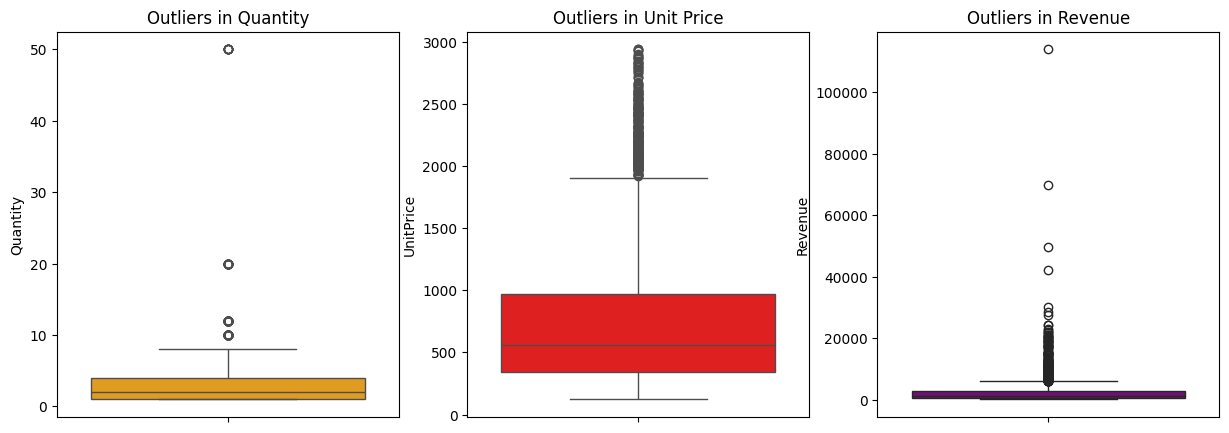

Interpretation: Extreme outliers exist in quantity and price, likely due to bulk orders or data entry errors.


/tmp/ipykernel_7467/2262139189.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index, palette="plasma")


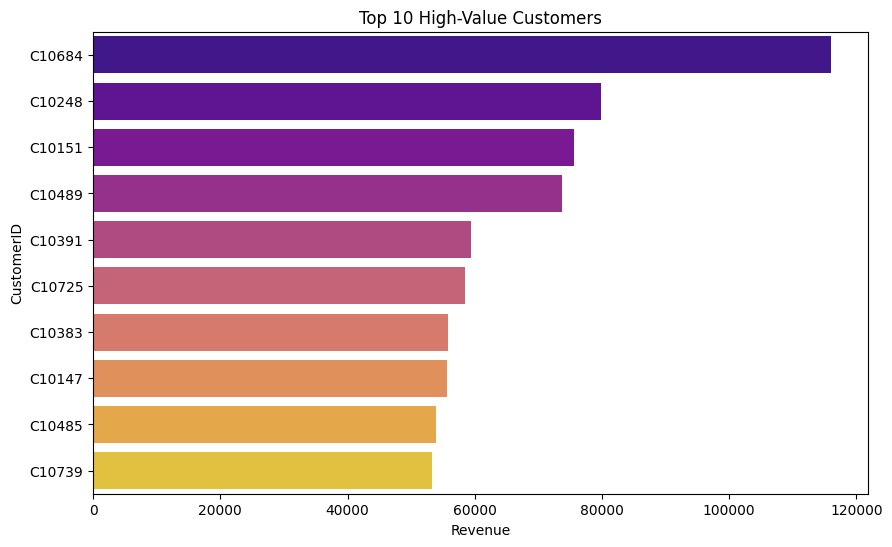

Interpretation: A small set of customers contribute disproportionately to total revenue.


In [23]:
# Step 6: Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Top 10 Countries by Sales Revenue
country_sales = data.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=country_sales.values, y=country_sales.index, palette="viridis")
plt.title("Top 10 Countries by Sales Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()
print("Interpretation: UK generates the highest sales, followed by other European countries.")

# 2. Top 10 Most Sold Products
top_products = data['Description'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette="magma")
plt.title("Top 10 Most Sold Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()
print("Interpretation: Everyday items like paper and bags dominate sales volume.")

# 3. Top 10 Products by Revenue
product_revenue = data.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=product_revenue.values, y=product_revenue.index, palette="coolwarm")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()
print("Interpretation: High-value items generate more revenue even if sold less frequently.")

# 4. Distribution of Customer Purchase Frequency
plt.figure(figsize=(8,5))
sns.histplot(data.groupby('CustomerID')['InvoiceNo'].count(), bins=30, kde=False, color="blue")
plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()
print("Interpretation: Most customers purchase only a few times, while a small group buys frequently.")

# 5. Distribution of Order Value
order_value = data.groupby('InvoiceNo')['Revenue'].sum()
plt.figure(figsize=(8,5))
sns.histplot(order_value, bins=30, kde=False, color="green")
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.show()
print("Interpretation: Majority of orders are low-value, but a few large orders contribute significantly.")

# 6. Outliers in Quantity, UnitPrice, Revenue
fig, axes = plt.subplots(1,3, figsize=(15,5))
sns.boxplot(y=data['Quantity'], ax=axes[0], color="orange")
axes[0].set_title("Outliers in Quantity")
sns.boxplot(y=data['UnitPrice'], ax=axes[1], color="red")
axes[1].set_title("Outliers in Unit Price")
sns.boxplot(y=data['Revenue'], ax=axes[2], color="purple")
axes[2].set_title("Outliers in Revenue")
plt.show()
print("Interpretation: Extreme outliers exist in quantity and price, likely due to bulk orders or data entry errors.")

# 7. Top 10 High-Value Customers
top_customers = data.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_customers.values, y=top_customers.index, palette="plasma")
plt.title("Top 10 High-Value Customers")
plt.xlabel("Revenue")
plt.ylabel("CustomerID")
plt.show()
print("Interpretation: A small set of customers contribute disproportionately to total revenue.")


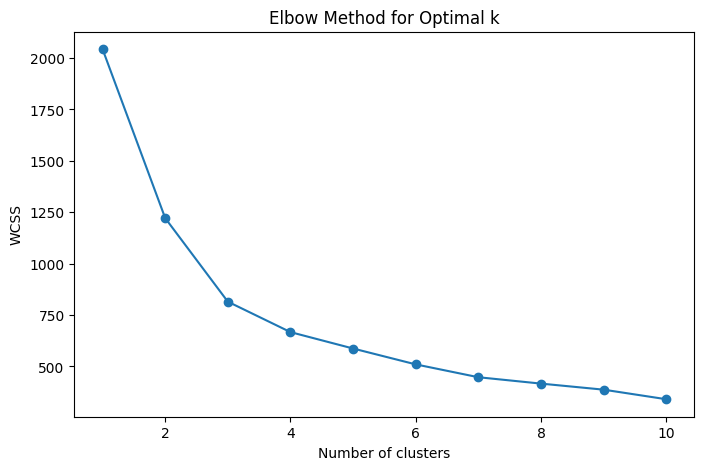

Cluster Summary:
   Cluster     Recency  Frequency      Monetary  NumCustomers
0        0   77.303371   8.078652  18362.545169           178
1        1  231.345972   3.559242   7304.088863           211
2        2   85.169014  12.957746  39598.901408            71
3        3   68.972851   3.343891   6850.026561           221


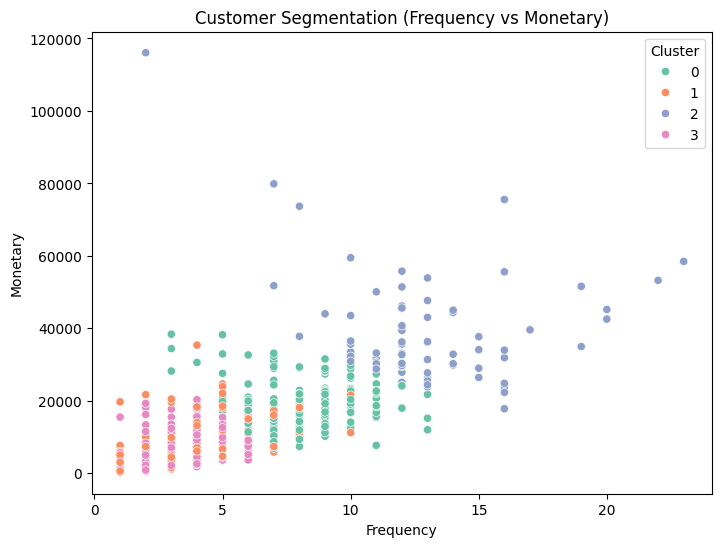

In [24]:
# Step 7: Customer Segmentation using K-Means

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# --- Select relevant features (RFM) ---
rfm_features = rfm[['Recency','Frequency','Monetary']]

# --- Normalize/scale the data ---
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# --- Use the Elbow Method to find optimal clusters ---
wcss = []  # within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

# --- Train K-Means model (choose k based on elbow curve, e.g., k=4) ---
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# --- Analyze each cluster ---
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean',
    'CustomerID':'count'
}).rename(columns={'CustomerID':'NumCustomers'}).reset_index()

print("Cluster Summary:")
print(cluster_summary)

# --- Visualize clusters (2D plot using Frequency vs Monetary) ---
plt.figure(figsize=(8,6))
sns.scatterplot(x=rfm['Frequency'], y=rfm['Monetary'], hue=rfm['Cluster'], palette="Set2")
plt.title("Customer Segmentation (Frequency vs Monetary)")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()


In [25]:
# Step 8: Cluster Interpretation

# Look at the cluster summary again
print("Cluster Summary:")
print(cluster_summary)

# --- Add interpretation labels based on RFM values ---
def interpret_cluster(row):
    if row['Recency'] < 30 and row['Frequency'] > 20 and row['Monetary'] > 5000:
        return "High Value Loyal"
    elif row['Recency'] > 180 and row['Frequency'] < 5:
        return "Inactive / At-Risk"
    elif row['Frequency'] >= 10 and row['Monetary'] < 2000:
        return "Frequent Low-Spend Buyer"
    elif row['Recency'] < 90 and row['Frequency'] < 10 and row['Monetary'] < 2000:
        return "Occasional Buyer"
    else:
        return "General Customer"

cluster_summary['Segment'] = cluster_summary.apply(interpret_cluster, axis=1)

print("\nCluster Interpretation:")
print(cluster_summary[['Cluster','Segment','NumCustomers','Recency','Frequency','Monetary']])


Cluster Summary:
   Cluster     Recency  Frequency      Monetary  NumCustomers
0        0   77.303371   8.078652  18362.545169           178
1        1  231.345972   3.559242   7304.088863           211
2        2   85.169014  12.957746  39598.901408            71
3        3   68.972851   3.343891   6850.026561           221

Cluster Interpretation:
   Cluster             Segment  NumCustomers     Recency  Frequency  \
0        0    General Customer           178   77.303371   8.078652   
1        1  Inactive / At-Risk           211  231.345972   3.559242   
2        2    General Customer            71   85.169014  12.957746   
3        3    General Customer           221   68.972851   3.343891   

       Monetary  
0  18362.545169  
1   7304.088863  
2  39598.901408  
3   6850.026561  


In [26]:
# Step 9: Business Recommendations

# Define recommendations linked to analysis
recommendations = {
    "High Value Loyal": [
        "Introduce a VIP loyalty program with exclusive rewards.",
        "Offer early access to new product launches.",
        "Send personalized thank-you campaigns to strengthen loyalty."
    ],
    "Inactive / At-Risk": [
        "Target with reactivation offers (e.g., 20% discount).",
        "Send personalized win-back emails highlighting trending products.",
        "Offer limited-time bundles to encourage return purchases."
    ],
    "Frequent Low-Spend Buyer": [
        "Promote bundle deals to increase basket size.",
        "Cross-sell complementary products during checkout.",
        "Introduce tiered discounts for higher spending thresholds."
    ],
    "Occasional Buyer": [
        "Send seasonal promotions to trigger repeat purchases.",
        "Offer free shipping vouchers to increase frequency.",
        "Provide personalized product recommendations based on past buys."
    ],
    "General Customer": [
        "Run standard awareness campaigns about new arrivals.",
        "Encourage account registration for personalized offers.",
        "Provide general discounts to maintain engagement."
    ]
}

# Attach recommendations to cluster summary
cluster_summary['Recommendations'] = cluster_summary['Segment'].map(recommendations)

# Display recommendations clearly
for _, row in cluster_summary.iterrows():
    print(f"\nCluster {row['Cluster']} - {row['Segment']}")
    print(f"Avg Recency: {row['Recency']:.1f} days | Avg Frequency: {row['Frequency']:.1f} | Avg Monetary: {row['Monetary']:.1f}")
    print("Recommendations:")
    for rec in row['Recommendations']:
        print(f"- {rec}")



Cluster 0 - General Customer
Avg Recency: 77.3 days | Avg Frequency: 8.1 | Avg Monetary: 18362.5
Recommendations:
- Run standard awareness campaigns about new arrivals.
- Encourage account registration for personalized offers.
- Provide general discounts to maintain engagement.

Cluster 1 - Inactive / At-Risk
Avg Recency: 231.3 days | Avg Frequency: 3.6 | Avg Monetary: 7304.1
Recommendations:
- Target with reactivation offers (e.g., 20% discount).
- Send personalized win-back emails highlighting trending products.
- Offer limited-time bundles to encourage return purchases.

Cluster 2 - General Customer
Avg Recency: 85.2 days | Avg Frequency: 13.0 | Avg Monetary: 39598.9
Recommendations:
- Run standard awareness campaigns about new arrivals.
- Encourage account registration for personalized offers.
- Provide general discounts to maintain engagement.

Cluster 3 - General Customer
Avg Recency: 69.0 days | Avg Frequency: 3.3 | Avg Monetary: 6850.0
Recommendations:
- Run standard awareness